In [8]:
import numpy as np
from matplotlib import pyplot as plt

In [9]:
class BernoulliBandit:
    def __init__(self, k=10):
        self.probs = np.random.uniform(size=k)
        self.best_k = np.argmax(self.probs)
        self.best_probs = self.probs[self.best_k]
        self. k = k

    def step(self, k):
        if np.random.rand() > self.probs[k]:
            return 0
        return 1

bandit = BernoulliBandit()
bandit.probs, bandit.best_k, bandit.best_probs

(array([0.45473695, 0.78548167, 0.19440424, 0.87505113, 0.36685369,
        0.45996153, 0.67756546, 0.66594333, 0.62713843, 0.1462519 ]),
 np.int64(3),
 np.float64(0.8750511349120742))

In [10]:
class Solver:
    def __init__(self, bandit:BernoulliBandit):
        self.bandit = bandit
        self.regrets = []
        self.regret = 0
        self.counts = np.array([0] * self.bandit.k)
    
    def run_one_step(self):
        raise NotImplementedError
    
    def update_regret(self, k):
        regret = self.bandit.best_probs - self.bandit.probs[k]
        self.regret += regret
        self.regrets.append(self.regret)

    def run(self, num_epochs):
        for _ in range(num_epochs):
            k = self.run_one_step()
            self.counts[k] += 1
            self.update_regret(k)

## ε-greedy

In [11]:
class EpsilonGreedy(Solver):
    def __init__(self, bandit, epsilon=0.01, init_reward=1):
        super().__init__(bandit)
        self.epsilon = epsilon
        self.reward = [init_reward] * self.bandit.k
    
    def run_one_step(self):
        k = -1
        if np.random.rand() < self.epsilon:
            k = np.random.randint(0, self.bandit.k)
        else:
            k = np.argmax(self.reward)
        
        reward = self.bandit.step(k)
        self.reward[k] += (1 / (self.counts[k] + 1)) * (reward - self.reward[k])
        return k


## 上置信界算法

In [12]:
class UCB(Solver):
    def __init__(self, bandit, conf=1, init_reward=1.0):
        super().__init__(bandit)
        self.reward = np.array([init_reward] * self.bandit.k)
        self.conf = conf
        self.step = 0
        
    
    def run_one_step(self):
        self.step += 1
        ucb = self.reward + self.conf * np.sqrt(np.log(self.step) / (2 * (self.counts + 1)))
        k = np.argmax(ucb)
        reward = self.bandit.step(k)
        self.reward[k] += (1 / (self.counts[k] + 1)) * (reward - self.reward[k])
        return k

## 汤普森采样算法

In [13]:
class ThompsonSampling(Solver):
    def __init__(self, bandit, init_reward=1.0):
        super().__init__(bandit)
        self._a = np.ones(shape=(self.bandit.k,),dtype=np.float32)
        self._b = np.ones(shape=(self.bandit.k,),dtype=np.float32)
        

    def run_one_step(self):
        sample = np.random.beta(self._a, self._b)
        k = np.argmax(sample)
        reward = self.bandit.step(k)
        
        self._a[k] += reward
        self._b[k] += (1-reward)

        return k
    

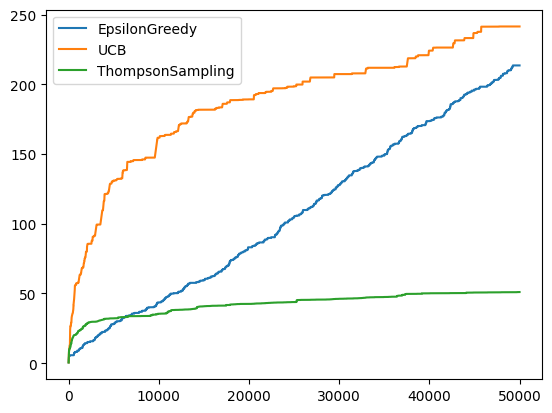

In [14]:
bandit = BernoulliBandit(10)

solver1 = EpsilonGreedy(bandit)
solver2 = UCB(bandit)
solver3 = ThompsonSampling(bandit)

names = ["EpsilonGreedy", "UCB", "ThompsonSampling"]
for idx, solver in enumerate([solver1, solver2, solver3]):
    np.random.seed(42)
    solver.run(50000)
    plt.plot(list(range(50000)), solver.regrets, label=names[idx])

plt.legend()
plt.show()